In [2]:
import json
import math
import pandas as pd
import numpy as np
from shapely.geometry import shape, Point
import gamspy as gp

# ----------------------------------------------------
# 1. Load Data & Geometries
# ----------------------------------------------------
# Load district population
df_pop = pd.read_excel(f"Data\جمعیت مناطق-1405-06-25.xlsx")
pop_dict = {
    1: 80807, 2: 76733, 3: 111013, 4: 147139, 5: 132984,
    6: 112896, 7: 206588, 8: 243563, 9: 78271, 10: 200702,
    11: 58334, 12: 155413, 13: 164413, 14: 160354, 15: 138247
}

# Parse 15 district polygons and calculate centroids
with open(r"Data\isfahan_raw.geojson", "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

persian_to_eng = {
    '۱': 1, '۲': 2, '۳': 3, '۴': 4, '۵': 5, '۶': 6, '۷': 7, '۸': 8,
    '۹': 9, '۱۰': 10, '۱۱': 11, '۱۲': 12, '۱۳': 13, '۱۴': 14, '۱۵': 15
}

districts = []
for feat in geojson_data["features"]:
    geom_type = feat.get("geometry", {}).get("type")
    props = feat.get("properties", {})
    name = props.get("name", "")
    admin_level = str(props.get("admin_level", ""))

    if geom_type not in ["Polygon", "MultiPolygon"] or admin_level != "9" or "خمینی" in name:
        continue

    d_num = None
    for p_num, val in persian_to_eng.items():
        if f"منطقه {p_num}" == name.strip() or f"منطقه {p_num} " in name:
            d_num = val
            break
    if d_num:
        poly = shape(feat["geometry"])
        districts.append({
            "id": f"D{d_num}",
            "d_num": d_num,
            "name": name,
            "lat": poly.centroid.y,
            "lon": poly.centroid.x,
            "geom": poly,
            "population": pop_dict[d_num]
        })

df_districts = pd.DataFrame(districts).sort_values("d_num").reset_index(drop=True)

In [3]:
df_districts

,id,d_num,name,lat,lon,geom,population
0,D1,1,منطقه ۱,32.657874,51.656211,"POLYGON ((51.6402311 32.6403622, 51.643313 32....",80807
1,D2,2,منطقه ۲,32.721811,51.580001,"MULTIPOLYGON (((51.5785474 32.7189195, 51.5786...",76733
2,D3,3,منطقه ۳,32.657969,51.684543,"POLYGON ((51.6917516 32.6769734, 51.6909783 32...",111013
3,D4,4,منطقه ۴,32.615095,51.791685,"POLYGON ((51.7022659 32.6638385, 51.7021617 32...",147139
4,D5,5,منطقه ۵,32.574687,51.651450,"POLYGON ((51.6663556 32.6357214, 51.6672484 32...",132984
5,D6,6,منطقه ۶,32.594013,51.707420,"POLYGON ((51.6893885 32.6385022, 51.6866001 32...",112896
6,D7,7,منطقه ۷,32.729184,51.678737,"POLYGON ((51.7082027 32.749689, 51.705367 32.7...",206588
7,D8,8,منطقه ۸,32.697953,51.648101,"POLYGON ((51.6572703 32.6738941, 51.6712126 32...",243563
8,D9,9,منطقه ۹,32.653344,51.606933,"POLYGON ((51.6431313 32.6464696, 51.6433613 32...",78271
9,D10,10,منطقه ۱۰,32.683612,51.726543,"POLYGON ((51.7291362 32.6667369, 51.7302651 32...",200702


In [4]:
refined_targets = np.load(r"Data\refined_targets.npy", allow_pickle=True)
target_counts = {d["id"]: 0 for d in districts}
for t in refined_targets:
    pt = Point(t["lon"], t["lat"])
    for d in districts:
        if d["geom"].contains(pt):
            target_counts[d["id"]] += 1
            break
refined_targets

array([{'id': 297227347, 'name': 'Badr Air Base', 'category': 'Aviation & Air Bases', 'type': 'airfield', 'lat': 32.6209518, 'lon': 51.6875522},
       {'id': 5643934331, 'name': 'Military/Defense Facility', 'category': 'Defense & Military', 'type': 'bunker', 'lat': 32.5659344, 'lon': 51.6541672},
       {'id': 6380568145, 'name': 'Military/Defense Facility', 'category': 'Defense & Military', 'type': 'checkpoint', 'lat': 32.5987561, 'lon': 51.6640166},
       {'id': 8495731262, 'name': 'بسیج', 'category': 'Defense & Military', 'type': 'complex', 'lat': 32.5529796, 'lon': 51.5019455},
       {'id': 8515927623, 'name': 'بسیج', 'category': 'Defense & Military', 'type': 'complex', 'lat': 32.6653343, 'lon': 51.5817841},
       {'id': 8515927624, 'name': 'بسیج', 'category': 'Defense & Military', 'type': 'complex', 'lat': 32.6653326, 'lon': 51.5817036},
       {'id': 8722031272, 'name': 'پایگاه هوایی هشتم شکاری', 'category': 'Aviation & Air Bases', 'type': 'airfield', 'lat': 32.7232001, 'lon'

In [5]:
# ----------------------------------------------------
# 3. Distance & Reachability Matrices (Haversine km)
# ----------------------------------------------------
stations = [
    {"name": "Qods (Malek Shahr)", "lat": 32.71472, "lon": 51.60472},
    {"name": "Baharestan",          "lat": 32.71528, "lon": 51.62528},
    {"name": "Golestan",            "lat": 32.71528, "lon": 51.62722},
    {"name": "Shahid Mofateh",      "lat": 32.71667, "lon": 51.64528},
    {"name": "Shahid Alikhani",     "lat": 32.71611, "lon": 51.66083},
    {"name": "Jaber",               "lat": 32.70889, "lon": 51.66722},
    {"name": "Kaveh",               "lat": 32.69806, "lon": 51.67417},
    {"name": "Shahid Chamran",      "lat": 32.68750, "lon": 51.67583},
    {"name": "Shahid Bahonar",      "lat": 32.67889, "lon": 51.67556},
    {"name": "Shohada",             "lat": 32.67222, "lon": 51.67250},
    {"name": "Takhti",              "lat": 32.66537, "lon": 51.67044},
    {"name": "Emam Hossein",        "lat": 32.65785, "lon": 51.66956},
    {"name": "Enqelab",             "lat": 32.64944, "lon": 51.66840},
    {"name": "Si-o-se Pol",         "lat": 32.63929, "lon": 51.66670},
    {"name": "Shari'ati",           "lat": 32.62830, "lon": 51.66550},
    {"name": "Azadi",               "lat": 32.62236, "lon": 51.66483},
    {"name": "Daneshgah-e Esfahan", "lat": 32.61444, "lon": 51.66371},
    {"name": "Kargar",              "lat": 32.60694, "lon": 51.66376},
    {"name": "Kuy-e Emam",          "lat": 32.59823, "lon": 51.66861},
    {"name": "Defa'-e Moqaddas (Soffeh)", "lat": 32.58983, "lon": 51.67031},
]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2)**2
    return 2 * R * math.asin(math.sqrt(a))

d_max_km = 4.5  # Acceptable evacuation radius between district centroids

A_data = []
for _, row1 in df_districts.iterrows():
    for _, row2 in df_districts.iterrows():
        dist = haversine(row1["lat"], row1["lon"], row2["lat"], row2["lon"])
        if dist <= d_max_km:
            A_data.append((row1["id"], row2["id"], 1))

B_data = []
for _, row in df_districts.iterrows():
    for idx, s in enumerate(stations):
        sub_id = f"S{idx+1}"
        dist = haversine(row["lat"], row["lon"], s["lat"], s["lon"])
        if dist <= d_max_km:
            B_data.append((row["id"], sub_id, 1))

In [6]:
# ----------------------------------------------------
# Distance-decayed strategic risk exposure per district
# ----------------------------------------------------
risk_scores = {d["id"]: 0.0 for d in districts}
for t in refined_targets:
    t_lat, t_lon = t["lat"], t["lon"]
    for d in districts:
        centroid = d["geom"].centroid
        dist = haversine(centroid.y, centroid.x, t_lat, t_lon)
        risk_scores[d["id"]] += 1 / (1 + dist)

max_risk = max(risk_scores.values()) if risk_scores else 1.0
risk_normalized = {k: v / max_risk for k, v in risk_scores.items()}

In [7]:
# ----------------------------------------------------
# 4. GAMSPy Mathematical Model
# ----------------------------------------------------
m = gp.Container()

# Sets
i = gp.Set(m, name="i", records=df_districts["id"].tolist())
alias_i = gp.Alias(m, name="ip", alias_with=i)
k = gp.Set(m, name="k", records=[f"S{idx+1}" for idx in range(len(stations))])

# Capacity specifications
C_val = 20000         # Capacity per standard modular shelter unit
CapSub_val = 15000    # Evacuation platform capacity per subway station

# Parameters
P = gp.Parameter(m, name="P", domain=[i], records=df_districts[["id", "population"]])
Risk = gp.Parameter(m, name="Risk", domain=[i],
                     records=pd.DataFrame(list(risk_normalized.items()), columns=["id", "score"]))
A = gp.Parameter(m, name="A", domain=[i, alias_i], records=pd.DataFrame(A_data, columns=["i", "ip", "value"]))
B = gp.Parameter(m, name="B", domain=[i, k], records=pd.DataFrame(B_data, columns=["i", "k", "value"]))

# Subway platform capacity parameter
CapSub_records = pd.DataFrame([{"k": f"S{idx+1}", "capacity": CapSub_val} for idx in range(len(stations))])
CapSub = gp.Parameter(m, name="CapSub", domain=[k], records=CapSub_records)

# Capacity specifications
C_val = 20000         # Capacity per standard modular shelter unit
CapSub_val = 15000    # Evacuation platform capacity per subway station
CapSub = gp.Parameter(m, name="CapSub", domain=[k], records=[[f"S{idx+1}", CapSub_val] for idx in range(len(stations))])

# Decision Variables
Y = gp.Variable(m, name="Y", domain=[i], type="Integer")  # Number of shelter units in district i
x = gp.Variable(m, name="x", domain=[i, alias_i], type="Positive")  # Evacuees from district i to shelter i'
w = gp.Variable(m, name="w", domain=[i, k], type="Positive")        # Evacuees from district i to subway k

# Equations
demand_cov = gp.Equation(m, name="demand_cov", domain=[i])
demand_cov[i] = gp.Sum(alias_i, x[i, alias_i]) + gp.Sum(k, w[i, k]) == P[i]

reach_shelter = gp.Equation(m, name="reach_shelter", domain=[i, alias_i])
reach_shelter[i, alias_i] = x[i, alias_i] <= P[i] * A[i, alias_i]

reach_subway = gp.Equation(m, name="reach_subway", domain=[i, k])
reach_subway[i, k] = w[i, k] <= P[i] * B[i, k]

cap_shelter = gp.Equation(m, name="cap_shelter", domain=[alias_i])
cap_shelter[alias_i] = gp.Sum(i, x[i, alias_i]) <= C_val * Y[alias_i]

cap_subway = gp.Equation(m, name="cap_subway", domain=[k])
cap_subway[k] = gp.Sum(i, w[i, k]) <= CapSub[k]

# Target risk scaling: Ensures districts with higher target density establish baseline shelter units
risk_coverage_fraction = 0.25
target_risk_rule = gp.Equation(m, name="target_risk_rule", domain=[i])
target_risk_rule[i] = Y[i] * C_val >= risk_coverage_fraction * Risk[i] * P[i]

# Objective: Minimize total shelter units constructed
obj = gp.Sum(i, Y[i])

shelter_model = gp.Model(
    m,
    name="Isfahan_Shelter_Location",
    equations=m.getEquations(),
    problem="MIP",
    sense=gp.Sense.MIN,
    objective=obj
)

shelter_model.solve()

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,NormalCompletion,OptimalGlobal,92.0,591.0,541.0,MIP,CPLEX,0.338


In [8]:
# ----------------------------------------------------
# 5. Extract Results
# ----------------------------------------------------
print("--- Optimization Results ---")
print(f"Objective Status: {shelter_model.status}")
print(f"Total Shelter Units Required: {int(shelter_model.objective_value)}")
results_df = Y.records[["i", "level"]].rename(columns={"i": "District", "level": "Shelter_Units"})
print(results_df[results_df["Shelter_Units"] > 0])

--- Optimization Results ---
Objective Status: ModelStatus.OptimalGlobal
Total Shelter Units Required: 92
   District  Shelter_Units
0        D1            4.0
1        D2            6.0
2        D3            1.0
3        D4            8.0
4        D5            5.0
5        D6            6.0
6        D7            9.0
7        D8            2.0
8        D9            3.0
9       D10            9.0
10      D11            5.0
11      D12            8.0
12      D13            9.0
13      D14           10.0
14      D15            7.0


In [9]:
# Evacuees from District i to District Shelter i'
x_results = (
    x.records[x.records["level"] > 0][["i", "ip", "level"]]
    .rename(
        columns={
            "i": "Origin_District",
            "ip": "Shelter_District",
            "level": "Evacuees",
        }
    )
    .sort_values(by=["Origin_District", "Evacuees"], ascending=[True, False])
    .reset_index(drop=True)
)

# Evacuees from District i to Subway Station k
w_results = (
    w.records[w.records["level"] > 0][["i", "k", "level"]]
    .rename(
        columns={
            "i": "Origin_District",
            "k": "Subway_Station",
            "level": "Evacuees",
        }
    )
    .sort_values(by=["Origin_District", "Evacuees"], ascending=[True, False])
    .reset_index(drop=True)
)

print("--- District-to-District Shelter Flows (X) ---")
print(x_results)

print("\n--- District-to-Subway Station Flows (W) ---")
print(w_results)

--- District-to-District Shelter Flows (X) ---
   Origin_District Shelter_District  Evacuees
0               D1               D1   76365.0
1               D2               D2   61666.0
2               D2              D11   15067.0
3               D3               D3   20000.0
4               D4               D4  147139.0
5               D5               D5  100000.0
6               D6               D6  100880.0
7               D7               D7  180000.0
8               D7              D14   18944.0
9               D8              D11   66662.0
10              D8               D8   40000.0
11              D9               D9   60000.0
12              D9              D11   18271.0
13             D10              D14  181056.0
14             D10              D10   19646.0
15             D11               D2   58334.0
16             D12              D12  155413.0
17             D13              D13  164413.0
18             D14              D10  160354.0
19             D15              D

In [10]:
shelter_model.toLatex(path="latex", generate_pdf=False)

LaTeX (.tex) file has been generated under latex\Isfahan_Shelter_Location.tex


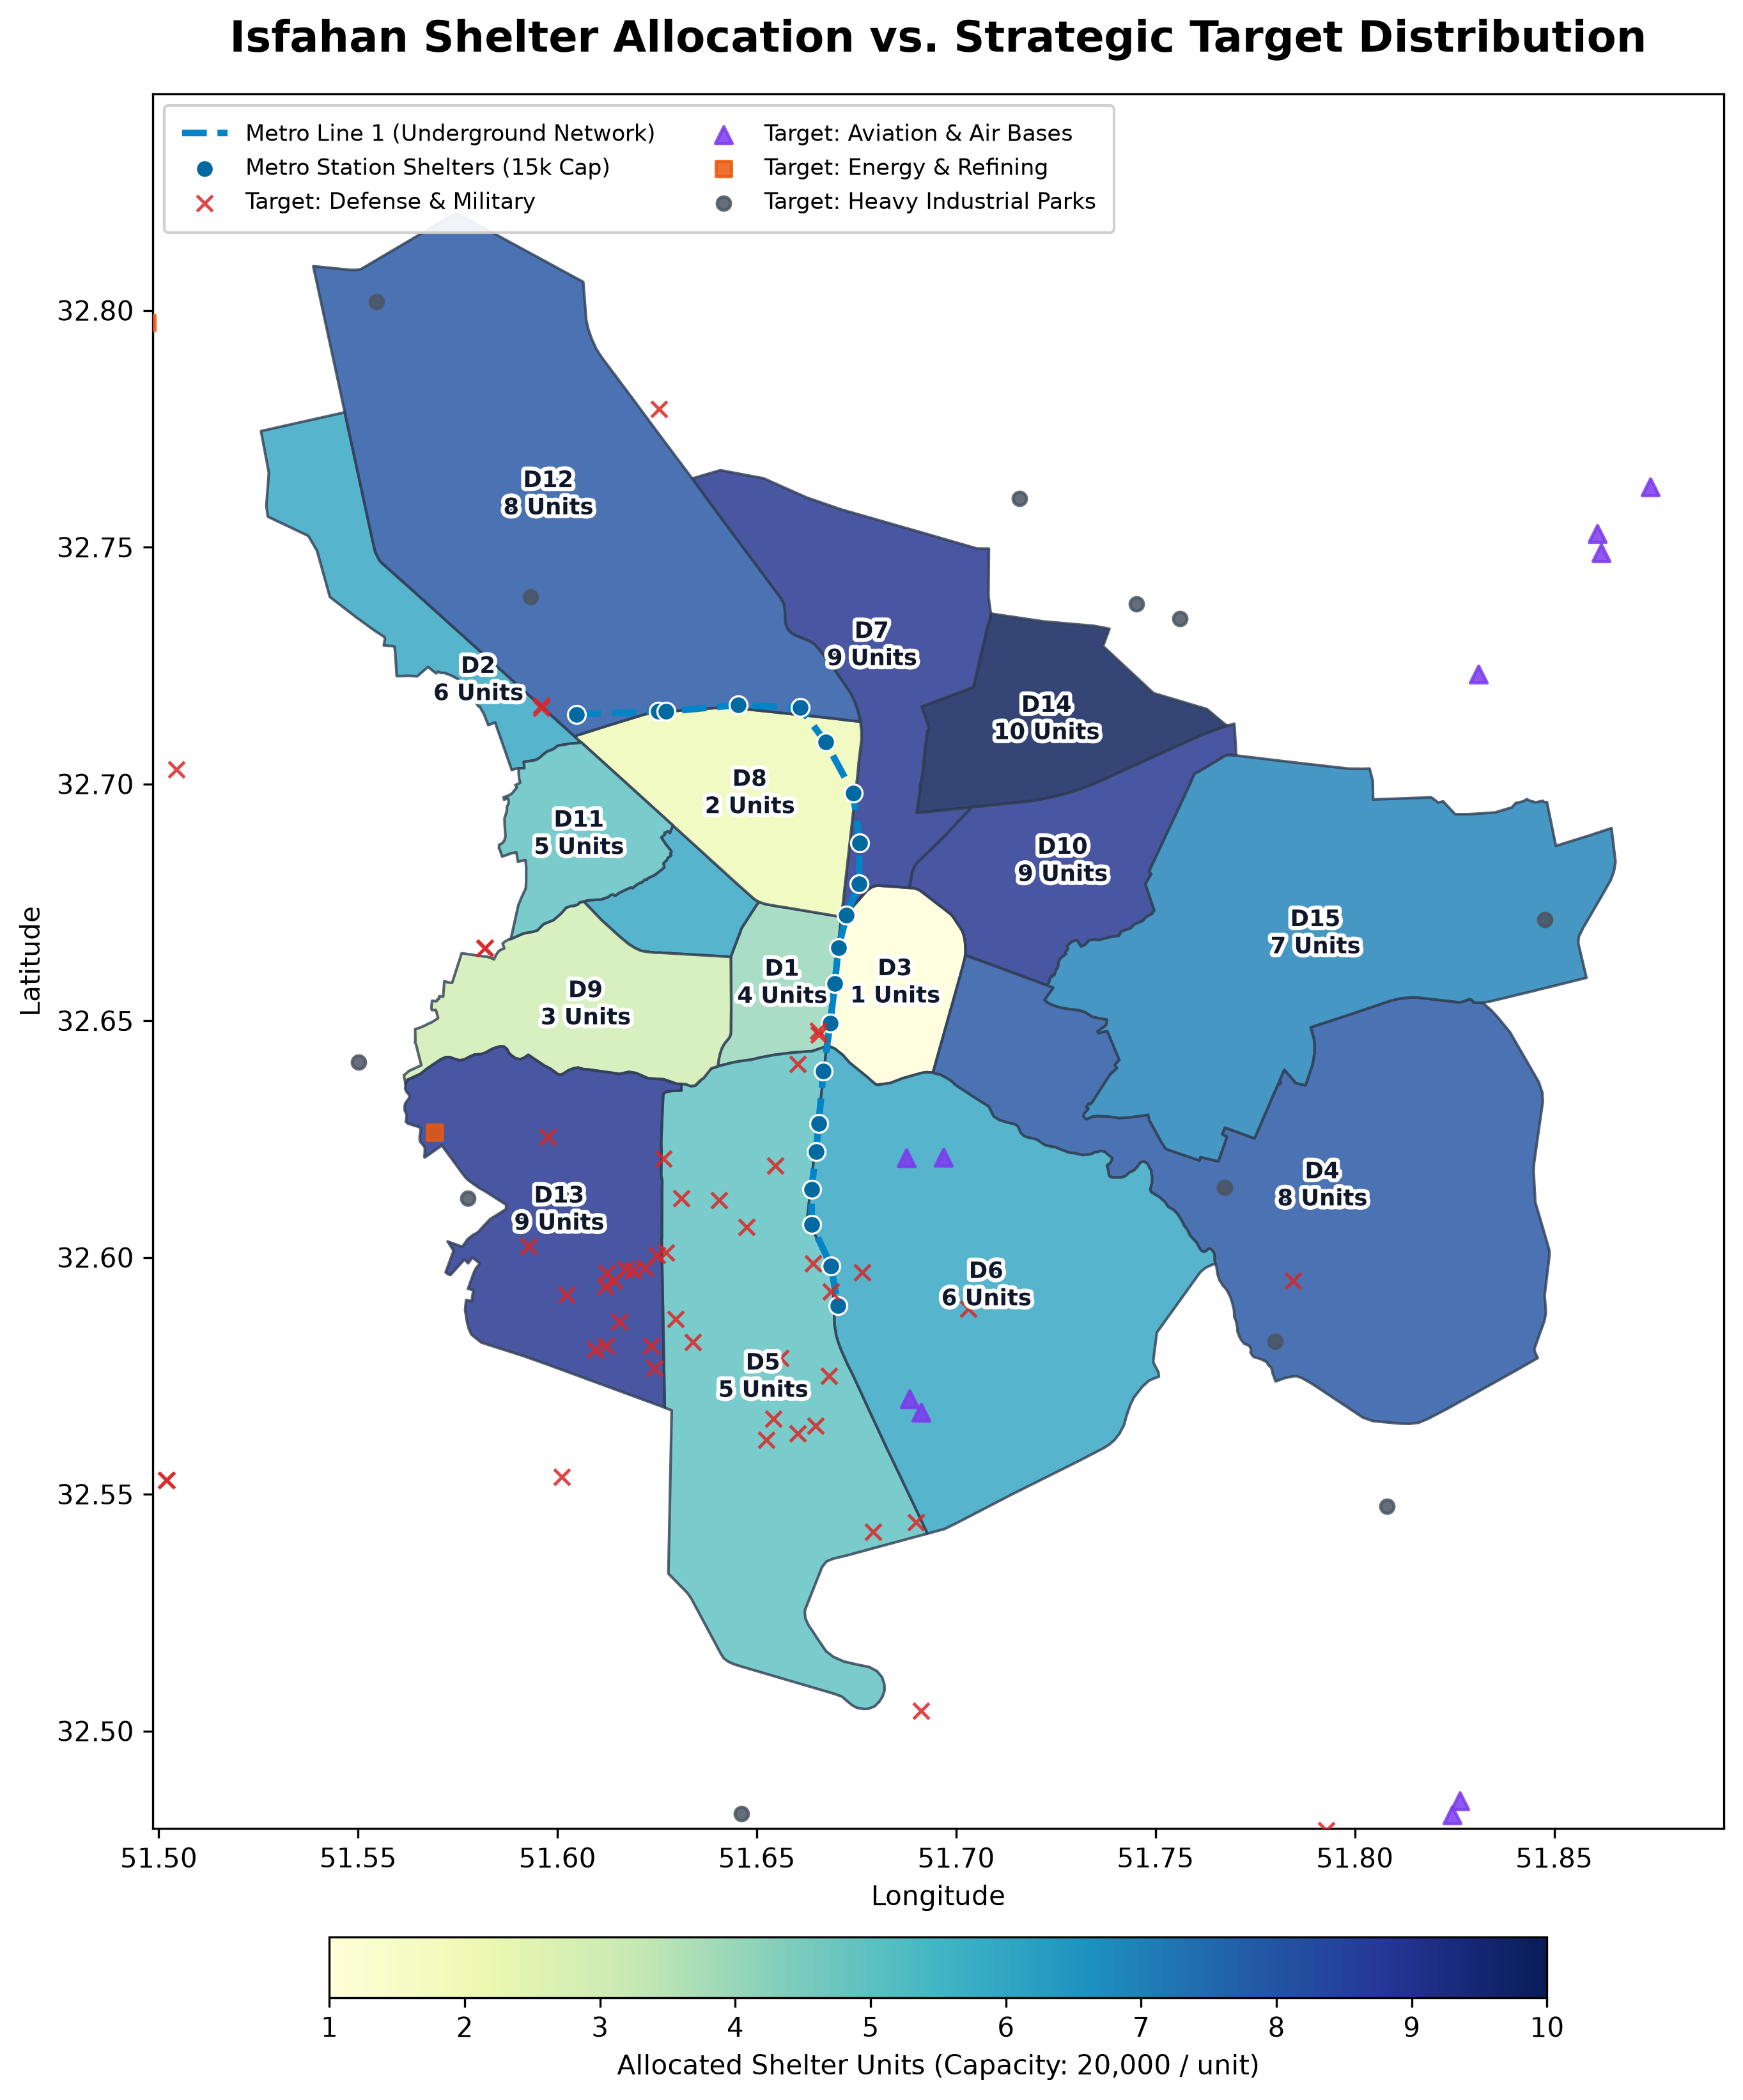

In [11]:
import geopandas as gpd
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Merge optimization output with district boundaries
merged_df = df_districts.merge(
    results_df, left_on="id", right_on="District"
)  #
gdf_districts = gpd.GeoDataFrame(
    merged_df, geometry="geom", crs="EPSG:4326"
)  #[cite: 1]

# 2. Prepare refined targets DataFrame
df_targets = pd.DataFrame(list(refined_targets))  #[cite: 1, 2]

# Target category palette and visual hierarchy
target_styles = {
    "Defense & Military": {"color": "#DC2626", "marker": "x", "s": 35},
    "Aviation & Air Bases": {"color": "#7C3AED", "marker": "^", "s": 40},
    "Energy & Refining": {"color": "#EA580C", "marker": "s", "s": 35},
    "Heavy Industrial Parks": {"color": "#4B5563", "marker": "o", "s": 25},
    "Nuclear": {"color": "#D97706", "marker": "*", "s": 55},
}  #

# 3. Canvas setup
fig, ax = plt.subplots(figsize=(13, 12), dpi=300)

# 4. District Choropleth (Allocated Modular Shelters)
gdf_districts.plot(
    column="Shelter_Units",  #[cite: 1]
    cmap="YlGnBu",
    linewidth=1.0,
    edgecolor="#334155",
    alpha=0.82,
    legend=True,
    legend_kwds={
        "label": "Allocated Shelter Units (Capacity: 20,000 / unit)",
        "orientation": "horizontal",
        "pad": 0.05,
        "shrink": 0.50,
    },
    ax=ax,
    zorder=1,
)

# 5. Metro Line 1 & Underground Shelter Stations
subway_lons = [s["lon"] for s in stations]  #[cite: 1, 2]
subway_lats = [s["lat"] for s in stations]  #[cite: 1, 2]

ax.plot(
    subway_lons,
    subway_lats,
    color="#0284C7",
    linewidth=2.5,
    linestyle="--",
    zorder=3,
    label="Metro Line 1 (Underground Network)",
)
ax.scatter(
    subway_lons,
    subway_lats,
    color="#0369A1",
    edgecolors="white",
    s=45,
    linewidth=0.8,
    zorder=4,
    label="Metro Station Shelters (15k Cap)",
)  #[cite: 1]

# 6. Scatter Strategic Refined Targets by Category
for cat, style in target_styles.items():
    cat_df = df_targets[df_targets["category"] == cat]  #[cite: 2]
    if not cat_df.empty:
        ax.scatter(
            cat_df["lon"],
            cat_df["lat"],
            color=style["color"],
            marker=style["marker"],
            s=style["s"],
            linewidth=1.2,
            alpha=0.85,
            zorder=5,
            label=f"Target: {cat}",
        )  #[cite: 2]

# 7. District Labels (District ID + Allocated Units)
for _, row in gdf_districts.iterrows():
    c = row["geom"].centroid  #[cite: 1]
    label_text = f"D{row['d_num']}\n{int(row['Shelter_Units'])} Units"  #[cite: 1]
    ax.annotate(
        text=label_text,
        xy=(c.x, c.y),
        ha="center",
        va="center",
        fontsize=8.5,
        fontweight="bold",
        color="#0F172A",
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
        zorder=6,
    )

# 8. Bounds & Polishing
minx, miny, maxx, maxy = gdf_districts.total_bounds
padding_x = (maxx - minx) * 0.08
padding_y = (maxy - miny) * 0.08
ax.set_xlim(minx - padding_x, maxx + padding_x)
ax.set_ylim(miny - padding_y, maxy + padding_y)

ax.set_title(
    "Isfahan Shelter Allocation vs. Strategic Target Distribution",
    fontsize=16,
    fontweight="bold",
    pad=16,
)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)

# Multi-column legend for compact visual layout
ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="#FFFFFF",
    framealpha=0.92,
    fontsize=8.5,
    ncol=2,
    borderpad=0.8,
)

plt.tight_layout()
plt.savefig("isfahan_shelter_and_targets_map.png", dpi=300, bbox_inches="tight")
plt.show()